# Machine Learning

In [23]:
# Machine Learning for EEG Feature Classification

# basic
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# notebook display
%matplotlib inline
sns.set_theme(style="whitegrid")

读取数据

In [24]:
feature_df = pd.read_csv("E:\EEG_project\data\processed\subject01_features.csv")

print(feature_df.shape)
feature_df.head()

(286, 360)


,Fp1_delta,Fp2_delta,F3_delta,F4_delta,C3_delta,C4_delta,P3_delta,P4_delta,O1_delta,O2_delta,...,parietal_theta_alpha_ratio,parietal_delta_alpha_ratio,temporal_theta_beta_ratio,temporal_alpha_beta_ratio,temporal_theta_alpha_ratio,temporal_delta_alpha_ratio,occipital_theta_beta_ratio,occipital_alpha_beta_ratio,occipital_theta_alpha_ratio,occipital_delta_alpha_ratio
0,-1.310930,-1.044057,-1.259704,-1.007682,-1.149320,-0.515209,-0.836206,-0.874192,-2.028693,-0.305758,...,0.641766,0.323491,1.238929,1.371608,0.903268,0.113207,1.043227,1.487109,0.701514,0.429605
1,-0.177707,-0.510573,-0.972117,-0.387270,-0.497661,-0.589908,-0.855177,-0.611738,-0.613392,-1.274785,...,0.734342,0.358642,0.838637,1.144519,0.732742,0.272636,0.617651,0.844062,0.731759,0.549643
2,-3.312816,-0.896658,-1.671914,-1.148300,-0.796402,-0.600296,-1.080035,-0.462435,-1.182772,-1.238946,...,0.922761,0.391086,1.360746,1.488252,0.914325,0.346253,2.019874,2.292912,0.880921,0.471736
3,-2.512582,-0.932189,-2.286642,-0.929797,-1.350020,-0.982329,-0.742956,-0.889003,-1.203754,-0.546215,...,0.764590,0.371535,1.127356,1.120922,1.005740,0.560041,2.028186,2.007456,1.010327,0.352284
4,-2.713897,-1.780116,-1.572438,-1.099905,-0.630580,-0.596021,-1.299483,-0.392364,-0.857162,-1.536077,...,1.031886,0.532809,1.154010,1.486789,0.776176,0.276436,1.843907,1.274732,1.446505,0.727400


# 准备阶段 & 定义模型

In [33]:
# separate features

# ===== 时间划分（temporal split） =====

split_idx = int(len(feature_df) * 0.7)

X_train = feature_df.iloc[:split_idx]
X_test  = feature_df.iloc[split_idx:]

创建人工标签（枕叶）
high_alpha / low_alpha

In [34]:
# =====  构建标签（high_alpha / low_alpha） =====

# 用 alpha_power 的中位数作为阈值
threshold = X_train["occipital_alpha"].median()

# 构建标签
X_train["label"] = feature_df["occipital_alpha"].apply(
    lambda x: "high_alpha" if x > threshold else "low_alpha"
)
X_test["label"] = feature_df["occipital_alpha"].apply(
    lambda x: "high_alpha" if x > threshold else "low_alpha"
)

# 查看分布
print(X_train["label"].value_counts())
print(X_test["label"].value_counts())

label
low_alpha     100
high_alpha    100
Name: count, dtype: int64
label
low_alpha     52
high_alpha    34
Name: count, dtype: int64


C:\Users\15122\AppData\Local\Temp\ipykernel_30668\1697643485.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["label"] = feature_df["occipital_alpha"].apply(
C:\Users\15122\AppData\Local\Temp\ipykernel_30668\1697643485.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test["label"] = feature_df["occipital_alpha"].apply(


In [35]:
y_train = X_train["label"]
y_test = X_test["label"]

In [36]:
occipital_keywords = [
    "O1", "O2", "OZ",
    "occipital"
]

def is_occipital_feature(col_name):
    col_upper = col_name.upper()
    return any(k.upper() in col_upper for k in occipital_keywords)

# 找到所有枕叶相关特征
occipital_features = [col for col in feature_df.columns if is_occipital_feature(col)]

print(f"枕叶相关特征数量: {len(occipital_features)}")
print(occipital_features)  # 预览

枕叶相关特征数量: 29
['O1_delta', 'O2_delta', 'POz_delta', 'Oz_delta', 'O1_theta', 'O2_theta', 'POz_theta', 'Oz_theta', 'O1_alpha', 'O2_alpha', 'POz_alpha', 'Oz_alpha', 'O1_beta', 'O2_beta', 'POz_beta', 'Oz_beta', 'O1_gamma', 'O2_gamma', 'POz_gamma', 'Oz_gamma', 'occipital_delta', 'occipital_theta', 'occipital_alpha', 'occipital_beta', 'occipital_gamma', 'occipital_theta_beta_ratio', 'occipital_alpha_beta_ratio', 'occipital_theta_alpha_ratio', 'occipital_delta_alpha_ratio']


In [38]:
cols_to_drop = occipital_features + [ 'label']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [40]:
print(X_train.shape)
print(X_test.shape)

(200, 331)
(86, 331)


In [41]:
# 特征标准化（只针对train数据）
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 比较不同模型

In [42]:
#时间序列交叉验证（只在训练集内部）
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

In [43]:
# 模型定义
# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', C=1.0, probability=True)  # probability=True为了ROC
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# CV评分
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='accuracy')

print("LR:", lr_scores, "mean:", lr_scores.mean())
print("SVM:", svm_scores, "mean:", svm_scores.mean())
print("RF:", rf_scores, "mean:", rf_scores.mean())

LR: [0.60606061 0.78787879 0.81818182 0.81818182 0.90909091] mean: 0.787878787878788
SVM: [0.66666667 0.75757576 0.81818182 0.54545455 0.84848485] mean: 0.7272727272727273
RF: [0.6969697  0.81818182 0.87878788 0.75757576 0.87878788] mean: 0.806060606060606


In [44]:
# 选择最佳模型

mean_scores = {
    "Logistic Regression": lr_scores.mean(),
    "SVM": svm_scores.mean(),
    "Random Forest": rf_scores.mean()
}

best_model_name = max(mean_scores, key=mean_scores.get)
print("\nBest model:", best_model_name)


Best model: Random Forest


In [45]:
# 在整个训练集上重新训练最佳模型
if best_model_name == "Logistic Regression":
    best_model = LogisticRegression(max_iter=1000)
    best_model.fit(X_train_scaled, y_train)
    X_test_used = X_test_scaled

elif best_model_name == "SVM":
    best_model = SVC(kernel='rbf', C=1.0, probability=True)
    best_model.fit(X_train_scaled, y_train)
    X_test_used = X_test_scaled

else:
    best_model = RandomForestClassifier(n_estimators=100, random_state=42)
    best_model.fit(X_train, y_train)
    X_test_used = X_test_scaled

# 评估最终验证集

In [46]:
# Accuracy + Classification Report
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test_used)

print("\n=== Final Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


=== Final Test Performance ===
Accuracy: 0.5
              precision    recall  f1-score   support

  high_alpha       0.43      0.85      0.57        34
   low_alpha       0.74      0.27      0.39        52

    accuracy                           0.50        86
   macro avg       0.58      0.56      0.48        86
weighted avg       0.62      0.50      0.47        86



c:\Users\15122\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


#待重新评估！！！！！！！
模型准确率约为0.5，high alpha类别的召回率为0.85，但整体precision和recall很不均衡，说明模型存在明显类别偏置，需要改善模型

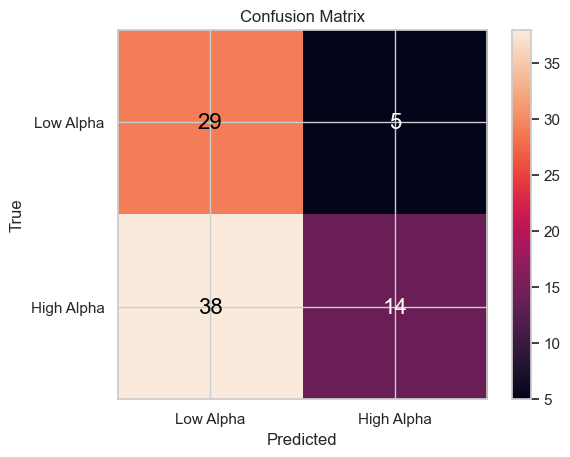

In [47]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

ticks = np.arange(2)
plt.xticks(ticks, ["Low Alpha", "High Alpha"])
plt.yticks(ticks, ["Low Alpha", "High Alpha"])

thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # 根据阈值来设置颜色
        color = "white" if value < thresh else "black"
        plt.text(
            j, i, value,
            ha="center", va="center",
            color=color,
            fontsize=16  # 调大字号，比如 12～16 
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [15]:
print(best_model.classes_)

['high_alpha' 'low_alpha']


c:\Users\15122\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


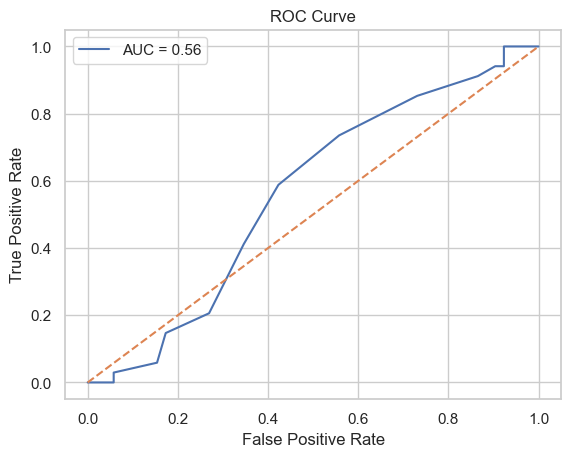

In [48]:
# ROC 曲线 + AUC
from sklearn.metrics import roc_curve, auc

# 概率预测
y_prob = best_model.predict_proba(X_test_used)[:, 0] # 注意这里哪个是“作为正类的那个类别"

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='high_alpha')
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

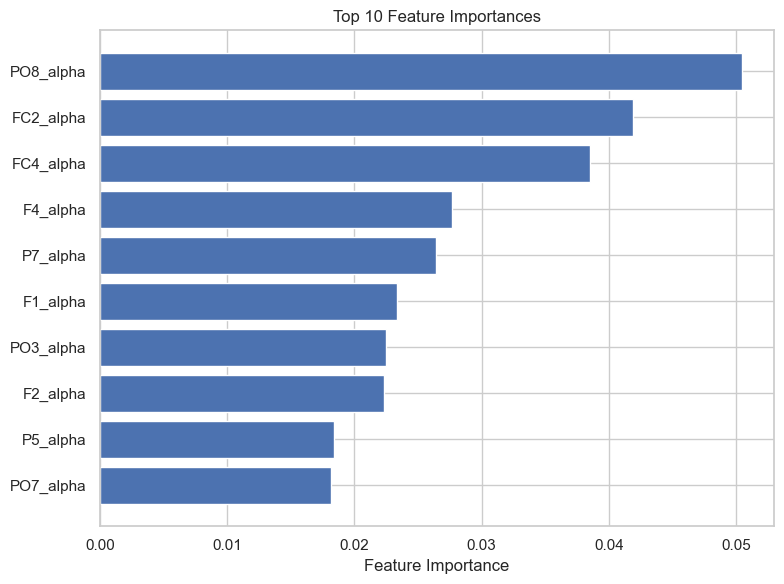

In [49]:
# Feature Importance（RF专属）只有当 RF 被选中才有意义
if best_model_name == "Random Forest":
    importances = best_model.feature_importances_
    feature_names = X.columns

    N = 10  # 想看前多少个可以改这个数
    indices = np.argsort(importances)[::-1]  # 从大到小排序后的索引
    top_indices = indices[:N]

    top_importances = importances[top_indices]
    top_features = feature_names[top_indices]

    # 3. 画图（横向条形图，更容易看清）
    plt.figure(figsize=(8, 6))  # 可以调整大小
    plt.barh(range(N), top_importances[::-1], align='center')  # 反转一下，让最重要的在最上面
    plt.yticks(range(N), top_features[::-1])
    plt.xlabel("Feature Importance")
    plt.title(f"Top {N} Feature Importances")
    plt.tight_layout()
    plt.show()

In [22]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results_df = pd.DataFrame([{
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, pos_label='high_alpha'),
    "recall": recall_score(y_test, y_pred, pos_label='high_alpha'),
    "f1_score": f1_score(y_test, y_pred, pos_label='high_alpha'),
    "roc_auc": roc_auc_score((y_test == 'high_alpha').astype(int), y_prob)
}])

output_path = r"E:\EEG_project\data\processed\model_results.csv"
results_df.to_csv(output_path, index=False)
print("model results saved to:", output_path)

results_df

model results saved to: E:\EEG_project\data\processed\model_results.csv


,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.709302,0.65,0.702703,0.675325,0.810259


# 尝试在验证集上用 F1 / macro-F1 选模型，而不是 accuracy

In [50]:
# 模型定义
# models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='rbf', C=1.0, probability=True)  # probability=True为了ROC
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# CV评分
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=tscv, scoring='f1_macro')
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=tscv, scoring='f1_macro')
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='f1_macro')

print("LR:", lr_scores, "mean:", lr_scores.mean())
print("SVM:", svm_scores, "mean:", svm_scores.mean())
print("RF:", rf_scores, "mean:", rf_scores.mean())

LR: [0.60018639 0.77463415 0.81666667 0.77083333 0.8563135 ] mean: 0.7637268074908474
SVM: [0.5254902  0.72727273 0.81666667 0.51707317 0.7605225 ] mean: 0.6694050514242171
RF: [0.65909091 0.80357143 0.87777778 0.71304348 0.81868132] mean: 0.7744329824764608


              precision    recall  f1-score   support

  high_alpha       0.72      0.82      0.77        34
   low_alpha       0.87      0.79      0.83        52

    accuracy                           0.80        86
   macro avg       0.80      0.81      0.80        86
weighted avg       0.81      0.80      0.80        86



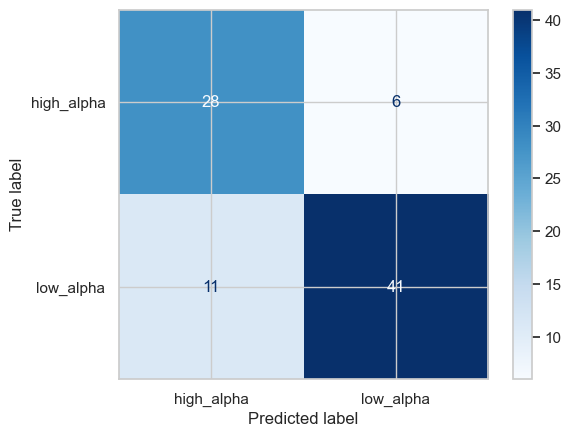

In [53]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. 标签编码
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # 训练时用编码后的 y
y_test_enc  = le.transform(y_test)

# 2. 训练模型
best_model.fit(X_train, y_train_enc)

# 3. 预测
y_pred_enc = best_model.predict(X_test)

# 4. 各项指标
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))

# 5. 混淆矩阵
cm = confusion_matrix(y_test_enc, y_pred_enc, labels=[0, 1])  # 或 range(len(le.classes_))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap='Blues')

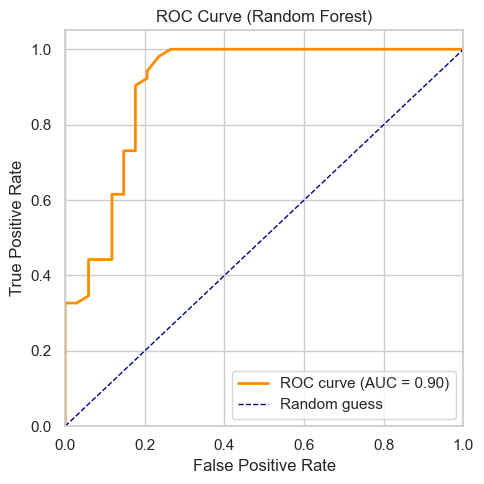

In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. 取得对“正类”的预测概率
# 假设 1 对应 high_alpha，如果你的编码相反，改 pos_label 即可
y_proba = best_model.predict_proba(X_test)[:, 1]

# 2. 计算 ROC
fpr, tpr, thresholds = roc_curve(y_test_enc, y_proba, pos_label=1)
roc_auc = auc(fpr, tpr)

# 3. 画图
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange',
         lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Top 10 important features:
       feature  importance
174  PO8_alpha    0.050460
136  FC2_alpha    0.041877
156  FC4_alpha    0.038550
121   F4_alpha    0.027710
130   P7_alpha    0.026414
147   F1_alpha    0.023391
159  PO3_alpha    0.022484
148   F2_alpha    0.022349
165   P5_alpha    0.018440
173  PO7_alpha    0.018187


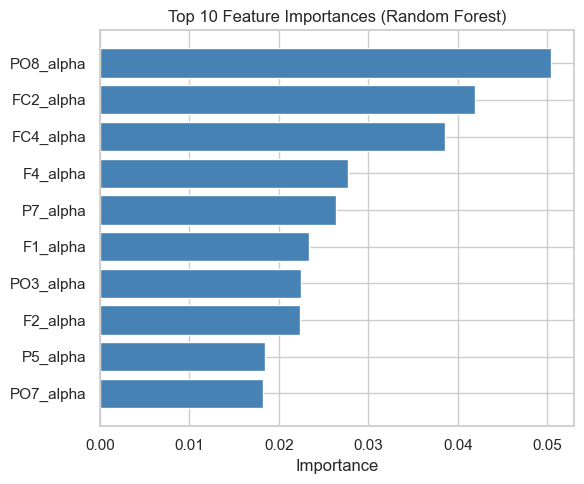

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 确保 X_train / X_test 是 DataFrame，这样有列名
feature_names = X_test.columns

# 1. 从随机森林中取出 importance
importances = best_model.feature_importances_

# 2. 组装成 DataFrame 并排序
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# 3. 只取 Top 10
top_n = 10
top_features = importance_df.head(top_n)

print("Top 10 important features:")
print(top_features)

# 4. 画条形图（横向）
plt.figure(figsize=(6, 5))
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.gca().invert_yaxis()  # 让最重要的在最上面
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()